In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/plantvillage_proyecto/data/plantvillage-dataset.zip'
local_extract = '/content/dataset'

if os.path.exists(os.path.join(local_extract, 'plantvillage dataset', 'color')):
    print("✅ Dataset ya está descomprimido")
else:
    print("⏳ Descomprimiendo... (3-5 min)")
    os.makedirs(local_extract, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract)
    print("✅ Dataset descomprimido")

color_path = '/content/dataset/plantvillage dataset/color'
print(f"\nClases encontradas: {len(os.listdir(color_path))}")

⏳ Descomprimiendo... (3-5 min)
✅ Dataset descomprimido

Clases encontradas: 38


In [4]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

splits_path = '/content/drive/MyDrive/plantvillage_proyecto/data'

# Verificar si los splits ya existen
if os.path.exists(f'{splits_path}/train_split.csv'):
    print("✅ Splits ya existen, cargándolos...")
    train_df = pd.read_csv(f'{splits_path}/train_split.csv')
    val_df = pd.read_csv(f'{splits_path}/val_split.csv')
    test_df = pd.read_csv(f'{splits_path}/test_split.csv')
else:
    print("⏳ Splits no encontrados, generándolos ahora...")

    # Reconstruir DataFrame desde el dataset local
    color_path = '/content/dataset/plantvillage dataset/color'
    classes = sorted(os.listdir(color_path))

    data = []
    for class_name in classes:
        class_dir = os.path.join(color_path, class_name)
        images = os.listdir(class_dir)
        parts = class_name.split('___')
        plant = parts[0].replace('_', ' ')
        disease = parts[1].replace('_', ' ') if len(parts) > 1 else 'healthy'

        for img_name in images:
            data.append({
                'class': class_name,
                'plant': plant,
                'disease': disease,
                'is_healthy': 'healthy' in disease.lower(),
                'image_path': os.path.join(class_dir, img_name)
            })

    df = pd.DataFrame(data)
    print(f"   Total imágenes: {len(df):,}")

    # Split estratificado 70/15/15
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['class'], random_state=42)

    # Guardar
    train_df.to_csv(f'{splits_path}/train_split.csv', index=False)
    val_df.to_csv(f'{splits_path}/val_split.csv', index=False)
    test_df.to_csv(f'{splits_path}/test_split.csv', index=False)
    print("✅ Splits generados y guardados")

# Corregir rutas para apuntar al storage local de Colab
def fix_path(old_path):
    parts = old_path.split('color/')
    return f'/content/dataset/plantvillage dataset/color/{parts[1]}'

train_df['image_path'] = train_df['image_path'].apply(fix_path)
val_df['image_path']   = val_df['image_path'].apply(fix_path)
test_df['image_path']  = test_df['image_path'].apply(fix_path)

print(f"\n✅ Train: {len(train_df):,} imágenes")
print(f"✅ Val:   {len(val_df):,} imágenes")
print(f"✅ Test:  {len(test_df):,} imágenes")

# Verificar que las rutas son correctas
from PIL import Image
test_img = Image.open(train_df['image_path'].iloc[0])
print(f"\n✅ Ruta verificada. Primera imagen: {test_img.size}")

⏳ Splits no encontrados, generándolos ahora...
   Total imágenes: 54,305
✅ Splits generados y guardados

✅ Train: 38,013 imágenes
✅ Val:   8,146 imágenes
✅ Test:  8,146 imágenes

✅ Ruta verificada. Primera imagen: (256, 256)


In [5]:
classes = sorted(train_df['class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_df['label'] = train_df['class'].map(class_to_idx)
val_df['label'] = val_df['class'].map(class_to_idx)
test_df['label'] = test_df['class'].map(class_to_idx)

print(f"✅ Total de clases: {len(classes)}")
print(f"\nPrimeras 5 clases con su índice:")
for c, i in list(class_to_idx.items())[:5]:
    print(f"  {i}: {c}")

# Guardar mapeo para usarlo en sprints siguientes
import json
with open('/content/drive/MyDrive/plantvillage_proyecto/data/class_mapping.json', 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': {str(k): v for k, v in idx_to_class.items()}}, f, indent=2)
print(f"\n✅ Mapeo guardado en class_mapping.json")

✅ Total de clases: 38

Primeras 5 clases con su índice:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy

✅ Mapeo guardado en class_mapping.json


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Tamaño estándar para CNNs preentrenadas
IMG_SIZE = 224

# Estadísticas de ImageNet (necesarias para transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformaciones para entrenamiento (CON augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),       # Voltear horizontal 50% del tiempo
    transforms.RandomVerticalFlip(p=0.3),         # Voltear vertical 30%
    transforms.RandomRotation(degrees=20),        # Rotar hasta ±20°
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2,
                           hue=0.05),             # Variar colores
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Trasladar
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transformaciones para validación/test (SIN augmentation, solo lo esencial)
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Transformaciones definidas")
print(f"\n📐 Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"📊 Augmentation aplicado SOLO a train")
print(f"\nTransforms de train:")
for t in train_transforms.transforms:
    print(f"  • {t.__class__.__name__}")

✅ Transformaciones definidas

📐 Tamaño de imagen: 224x224
📊 Augmentation aplicado SOLO a train

Transforms de train:
  • Resize
  • RandomHorizontalFlip
  • RandomVerticalFlip
  • RandomRotation
  • ColorJitter
  • RandomAffine
  • ToTensor
  • Normalize


In [7]:
class PlantVillageDataset(Dataset):
    """Dataset personalizado que carga imágenes desde un DataFrame."""

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

# Crear los datasets
train_dataset = PlantVillageDataset(train_df, transform=train_transforms)
val_dataset   = PlantVillageDataset(val_df,   transform=eval_transforms)
test_dataset  = PlantVillageDataset(test_df,  transform=eval_transforms)

print(f"✅ Train dataset: {len(train_dataset):,} imágenes")
print(f"✅ Val dataset:   {len(val_dataset):,} imágenes")
print(f"✅ Test dataset:  {len(test_dataset):,} imágenes")

# Probar carga de un sample
img, label = train_dataset[0]
print(f"\n🔍 Sample 0:")
print(f"   • Tensor shape: {img.shape}")
print(f"   • Tipo: {img.dtype}")
print(f"   • Rango: [{img.min():.3f}, {img.max():.3f}]")
print(f"   • Label: {label} ({idx_to_class[label]})")

✅ Train dataset: 38,013 imágenes
✅ Val dataset:   8,146 imágenes
✅ Test dataset:  8,146 imágenes

🔍 Sample 0:
   • Tensor shape: torch.Size([3, 224, 224])
   • Tipo: torch.float32
   • Rango: [-2.118, 0.536]
   • Label: 2 (Apple___Cedar_apple_rust)


In [8]:
BATCH_SIZE = 64  # Cuántas imágenes procesa el modelo a la vez
NUM_WORKERS = 2  # Hilos para cargar datos en paralelo

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Mezclar para que el modelo no aprenda el orden
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches:   {len(val_loader)}")
print(f"✅ Test batches:  {len(test_loader)}")

# Probar un batch
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 Primer batch:")
print(f"   • Imágenes: {batch_imgs.shape}  (batch, canales, alto, ancho)")
print(f"   • Labels:   {batch_labels.shape}")
print(f"   • Labels únicos: {batch_labels.unique().tolist()[:10]}...")

✅ Train batches: 594
✅ Val batches:   128
✅ Test batches:  128

🔍 Primer batch:
   • Imágenes: torch.Size([64, 3, 224, 224])  (batch, canales, alto, ancho)
   • Labels:   torch.Size([64])
   • Labels únicos: [3, 4, 5, 7, 8, 9, 10, 11, 12, 13]...


In [10]:
import os
fig_path = '/content/drive/MyDrive/plantvillage_proyecto/figuras'
os.makedirs(fig_path, exist_ok=True)
print(f"✅ Carpeta de figuras lista: {fig_path}")

✅ Carpeta de figuras lista: /content/drive/MyDrive/plantvillage_proyecto/figuras


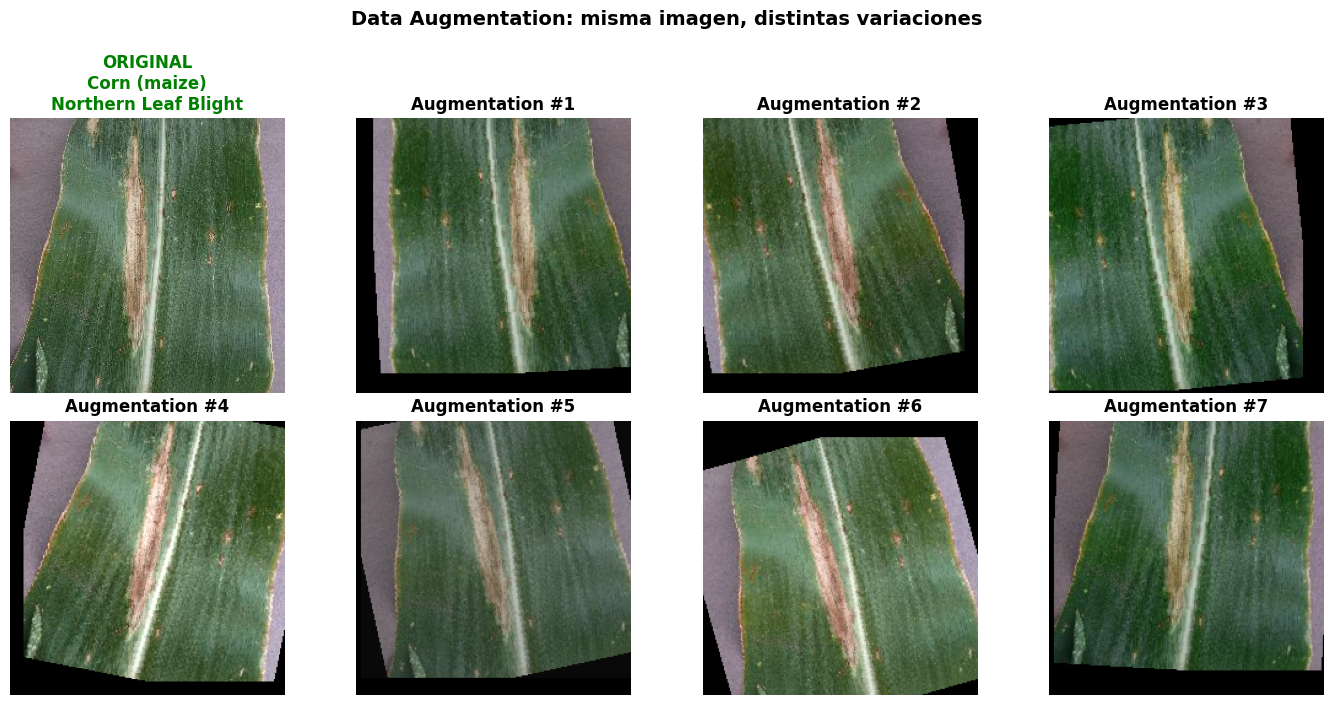

✅ Gráfica guardada en figuras/06_augmentation.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig_path = '/content/drive/MyDrive/plantvillage_proyecto/figuras'

def denormalize(tensor):
    """Revertir la normalización para visualizar."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return tensor * std + mean

# Tomar una imagen y aplicar el augmentation 7 veces
sample_idx = 100
original_img = Image.open(train_df['image_path'].iloc[sample_idx]).convert('RGB')
sample_class = train_df['class'].iloc[sample_idx].replace('___', '\n').replace('_', ' ')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Primera celda: imagen original (sin augmentation)
axes[0, 0].imshow(original_img)
axes[0, 0].set_title(f'ORIGINAL\n{sample_class}', fontweight='bold', color='green')
axes[0, 0].axis('off')

# Las otras 7 celdas: misma imagen con augmentation aleatorio
for i in range(1, 8):
    row, col = i // 4, i % 4
    augmented = train_transforms(original_img)
    img_show = denormalize(augmented).permute(1, 2, 0).clip(0, 1).numpy()
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(f'Augmentation #{i}', fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('Data Augmentation: misma imagen, distintas variaciones', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{fig_path}/06_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada en figuras/06_augmentation.png")

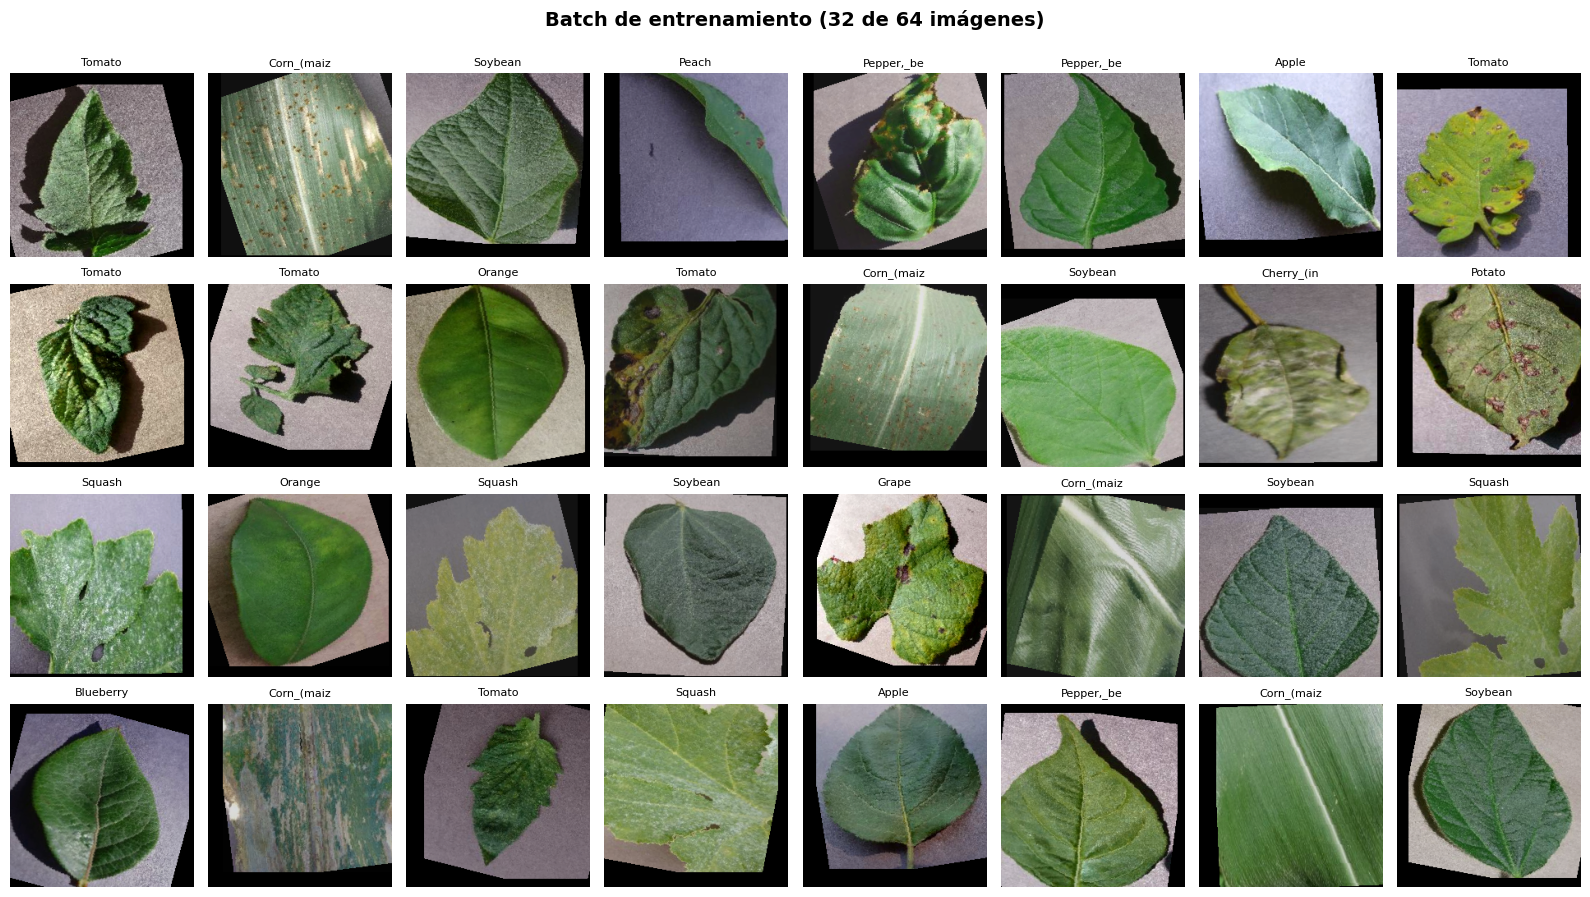

✅ Gráfica guardada


In [12]:
fig, axes = plt.subplots(4, 8, figsize=(16, 9))

for i in range(32):
    row, col = i // 8, i % 8
    img_show = denormalize(batch_imgs[i]).permute(1, 2, 0).clip(0, 1).numpy()
    axes[row, col].imshow(img_show)
    label_idx = batch_labels[i].item()
    short_name = idx_to_class[label_idx].split('___')[0][:10]
    axes[row, col].set_title(short_name, fontsize=8)
    axes[row, col].axis('off')

plt.suptitle(f'Batch de entrenamiento (32 de {BATCH_SIZE} imágenes)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{fig_path}/07_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

In [13]:
import time

print("⏱️ Probando velocidad del DataLoader...")
start = time.time()
batches_to_test = 10

for i, (imgs, labels) in enumerate(train_loader):
    if i >= batches_to_test:
        break

elapsed = time.time() - start
imgs_per_sec = (batches_to_test * BATCH_SIZE) / elapsed
print(f"✅ {batches_to_test} batches procesados en {elapsed:.1f}s")
print(f"⚡ Velocidad: {imgs_per_sec:.0f} imágenes/segundo")

# Estimación de tiempo por época
total_imgs = len(train_dataset)
est_seconds = total_imgs / imgs_per_sec
print(f"\n📊 Estimación: una época completa tardará ~{est_seconds/60:.1f} minutos solo en cargar datos")
print(f"   (el entrenamiento real será mayor por el cómputo en GPU)")

⏱️ Probando velocidad del DataLoader...
✅ 10 batches procesados en 9.1s
⚡ Velocidad: 70 imágenes/segundo

📊 Estimación: una época completa tardará ~9.0 minutos solo en cargar datos
   (el entrenamiento real será mayor por el cómputo en GPU)


In [14]:
# Guardar configuración común que usaremos en todos los sprints siguientes
config = {
    'IMG_SIZE': IMG_SIZE,
    'BATCH_SIZE': BATCH_SIZE,
    'NUM_WORKERS': NUM_WORKERS,
    'NUM_CLASSES': len(classes),
    'IMAGENET_MEAN': IMAGENET_MEAN,
    'IMAGENET_STD': IMAGENET_STD,
}

import json
with open('/content/drive/MyDrive/plantvillage_proyecto/data/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Configuración guardada en config.json")
print("\n📝 Resumen del pipeline:")
print(f"   • Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"   • Batch size: {BATCH_SIZE}")
print(f"   • Total clases: {len(classes)}")
print(f"   • Augmentation: HorizontalFlip, VerticalFlip, Rotation, ColorJitter, Affine")
print(f"   • Normalización: ImageNet stats")

✅ Configuración guardada en config.json

📝 Resumen del pipeline:
   • Tamaño de imagen: 224x224
   • Batch size: 64
   • Total clases: 38
   • Augmentation: HorizontalFlip, VerticalFlip, Rotation, ColorJitter, Affine
   • Normalización: ImageNet stats
